<a href="https://colab.research.google.com/github/SHAHAB-UDDIN54/Deep-learning-The-Deep-End-/blob/main/CNN_Practical_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Practical Assignment
## Dataset: CIFAR-10 (60,000 images, 10 classes)
### Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

---
This notebook walks through all 11 tasks step by step with detailed comments.

## 📦 Install & Import Libraries

In [1]:
# ── Install required libraries (run once) ──────────────────────────────────────
# Uncomment the line below if running for the first time
# !pip install tensorflow matplotlib numpy scikit-learn seaborn

# ── Standard imports ──────────────────────────────────────────────────────────
import numpy as np                        # Numerical operations
import matplotlib.pyplot as plt           # Plotting and visualization
import seaborn as sns                     # Heatmaps and styled plots

# ── TensorFlow / Keras imports ────────────────────────────────────────────────
import tensorflow as tf                   # Deep learning framework
from tensorflow import keras              # High-level Keras API
from tensorflow.keras import layers, models  # Layer building blocks
from tensorflow.keras.datasets import cifar10  # CIFAR-10 built-in dataset
from tensorflow.keras.utils import to_categorical  # One-hot encoding helper

# ── Scikit-learn imports ───────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report  # Evaluation tools

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)        # Fix NumPy random seed for consistent results
tf.random.set_seed(42)    # Fix TensorFlow random seed

print("✅ All libraries imported successfully!")
print(f"   TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully!
   TensorFlow version: 2.19.0


---
## Task 1 & 2 — Dataset Selection and Data Loading
**Dataset chosen:** CIFAR-10
- 60,000 colour images (32×32 pixels, 3 RGB channels)
- 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- Built into Keras — no manual download required

In [2]:
# ── Task 2: Load the CIFAR-10 dataset ─────────────────────────────────────────
# keras.datasets.cifar10.load_data() returns two tuples:
#   (x_train, y_train) – 50,000 training images and their labels
#   (x_test,  y_test)  – 10,000 test images and their labels
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# ── Human-readable class names (index 0–9 maps to the list below) ─────────────
class_names = [
    'airplane',    # label 0
    'automobile',  # label 1
    'bird',        # label 2
    'cat',         # label 3
    'deer',        # label 4
    'dog',         # label 5
    'frog',        # label 6
    'horse',       # label 7
    'ship',        # label 8
    'truck'        # label 9
]

# ── Print basic shape information ─────────────────────────────────────────────
print("📊 Dataset shapes:")
print(f"   x_train : {x_train.shape}  → (samples, height, width, channels)")
print(f"   y_train : {y_train.shape}  → (samples, 1) integer labels")
print(f"   x_test  : {x_test.shape}")
print(f"   y_test  : {y_test.shape}")
print(f"\n   Pixel value range (raw): {x_train.min()} – {x_train.max()}")
print(f"   Number of classes      : {len(class_names)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
📊 Dataset shapes:
   x_train : (50000, 32, 32, 3)  → (samples, height, width, channels)
   y_train : (50000, 1)  → (samples, 1) integer labels
   x_test  : (10000, 32, 32, 3)
   y_test  : (10000, 1)

   Pixel value range (raw): 0 – 255
   Number of classes      : 10


---
## Task 3 — Preprocessing: Normalisation & Label Encoding

In [3]:
# ── Step 3a: Normalise pixel values from [0, 255] → [0.0, 1.0] ───────────────
# Dividing by 255.0 scales each pixel so all values sit between 0 and 1.
# This helps gradient descent converge faster and more stably.
x_train = x_train.astype('float32') / 255.0   # Convert dtype + scale
x_test  = x_test.astype('float32')  / 255.0

print(f"✅ After normalisation — pixel range: {x_train.min():.1f} – {x_train.max():.1f}")

# ── Step 3b: One-hot encode the labels ────────────────────────────────────────
# y_train contains integers like [3], [7], [1] …
# to_categorical converts each integer into a binary vector of length 10.
# Example:  label 3  →  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# This is required because the final Dense layer uses 'softmax' with 10 outputs.
y_train_cat = to_categorical(y_train, num_classes=10)  # Shape: (50000, 10)
y_test_cat  = to_categorical(y_test,  num_classes=10)  # Shape: (10000, 10)

print(f"   y_train_cat shape : {y_train_cat.shape}")
print(f"   Example (label {y_train[0][0]} → {y_train_cat[0]})")

# ── Step 3c: Train / Validation split ─────────────────────────────────────────
# We carve out the last 10,000 training samples as a validation set.
# This lets us monitor performance on unseen data after every epoch.
VALIDATION_SPLIT = 0.2    # 20% of 50,000 = 10,000 validation images
split_index = int(len(x_train) * (1 - VALIDATION_SPLIT))  # = 40,000

x_val   = x_train[split_index:]     # Validation images  (10,000)
y_val   = y_train_cat[split_index:] # Validation labels  (10,000)
x_train_final = x_train[:split_index]      # Training images    (40,000)
y_train_final = y_train_cat[:split_index]  # Training labels    (40,000)

print(f"\n✅ Split complete:")
print(f"   Training   : {x_train_final.shape[0]} images")
print(f"   Validation : {x_val.shape[0]} images")
print(f"   Test       : {x_test.shape[0]} images")

✅ After normalisation — pixel range: 0.0 – 1.0
   y_train_cat shape : (50000, 10)
   Example (label 6 → [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.])

✅ Split complete:
   Training   : 40000 images
   Validation : 10000 images
   Test       : 10000 images


---
## Task 4 — Visualise 10 Sample Images

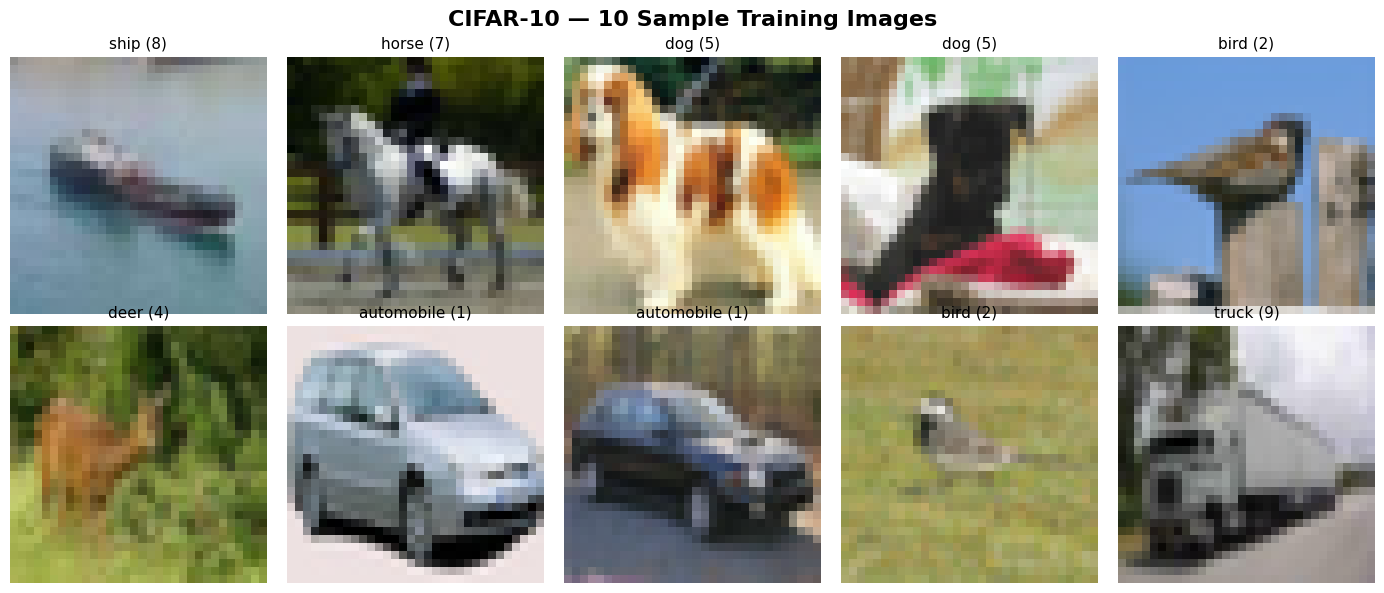

✅ Sample images visualised.


In [4]:
# ── Task 4: Display 10 random training images with their class labels ──────────

fig, axes = plt.subplots(2, 5, figsize=(14, 6))   # 2 rows × 5 columns = 10 subplots
fig.suptitle('CIFAR-10 — 10 Sample Training Images', fontsize=16, fontweight='bold')

# Pick 10 random indices from the training set
random_indices = np.random.choice(len(x_train_final), size=10, replace=False)

for idx, ax in zip(random_indices, axes.flatten()):  # Pair each index with one subplot
    # imshow expects values in [0,1] for float arrays — our data is already normalised
    ax.imshow(x_train_final[idx])

    # Recover the integer label: argmax finds which class has value 1
    label_int  = np.argmax(y_train_final[idx])
    label_name = class_names[label_int]

    ax.set_title(f'{label_name} ({label_int})', fontsize=11)
    ax.axis('off')   # Hide axis ticks for cleaner look

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')  # Save figure
plt.show()
print("✅ Sample images visualised.")

---
## Task 5 — Build the CNN Architecture (with Extra Conv Layer)

Architecture overview:
```
Input (32×32×3)
  → Conv2D(32) + BatchNorm + ReLU + MaxPool          # Block 1
  → Conv2D(64) + BatchNorm + ReLU + MaxPool          # Block 2
  → Conv2D(128) + BatchNorm + ReLU + MaxPool         # Block 3  ← ADDED LAYER
  → Flatten → Dense(256) → Dropout → Dense(10, softmax)
```

In [5]:
# ── Task 5: Define the CNN model ──────────────────────────────────────────────

def build_cnn(num_filters_1=32, num_filters_2=64, num_filters_3=128,
              learning_rate=0.001):
    """
    Build and compile a CNN for CIFAR-10.

    Parameters
    ----------
    num_filters_1  : int  – filters in Conv block 1
    num_filters_2  : int  – filters in Conv block 2
    num_filters_3  : int  – filters in Conv block 3 (extra layer, Task 5)
    learning_rate  : float – Adam optimiser learning rate
    """

    model = models.Sequential(name='CIFAR10_CNN')

    # ── INPUT ─────────────────────────────────────────────────────────────────
    # Explicitly declare input shape: 32 px × 32 px × 3 colour channels
    model.add(layers.Input(shape=(32, 32, 3)))

    # ── BLOCK 1 ───────────────────────────────────────────────────────────────
    # Conv2D: 32 learnable 3×3 filters slide over the image, detecting low-level
    # features (edges, colours, gradients).
    model.add(layers.Conv2D(num_filters_1, kernel_size=(3, 3), padding='same'))
    # BatchNormalization: normalises activations → reduces internal covariate shift
    model.add(layers.BatchNormalization())
    # ReLU: max(0, x) introduces non-linearity; kills negative activations
    model.add(layers.Activation('relu'))
    # MaxPooling: 2×2 window keeps only the largest value → halves spatial size
    # Output: 16×16×32
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    # Dropout: randomly zeros 25% of neurons during training → prevents overfitting
    model.add(layers.Dropout(0.25))

    # ── BLOCK 2 ───────────────────────────────────────────────────────────────
    # 64 filters — deeper layer detects more complex patterns (textures, shapes)
    model.add(layers.Conv2D(num_filters_2, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    # Output after pooling: 8×8×64
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # ── BLOCK 3 (ADDITIONAL CONVOLUTIONAL LAYER — Task 5 requirement) ─────────
    # 128 filters — captures high-level semantic features (object parts)
    model.add(layers.Conv2D(num_filters_3, kernel_size=(3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    # Output after pooling: 4×4×128
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))

    # ── FULLY CONNECTED HEAD ──────────────────────────────────────────────────
    # Flatten: convert 3D feature map (4×4×128 = 2048 values) into a 1D vector
    model.add(layers.Flatten())
    # Dense(256): learns global combinations of features
    model.add(layers.Dense(256, activation='relu'))
    # Dropout(0.5): aggressive regularisation before the output layer
    model.add(layers.Dropout(0.5))
    # Output layer: 10 neurons (one per class), softmax converts logits to probabilities
    model.add(layers.Dense(10, activation='softmax'))

    # ── COMPILE ───────────────────────────────────────────────────────────────
    # Adam: adaptive learning rate optimiser (good default choice)
    # categorical_crossentropy: correct loss for multi-class one-hot labels
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ── Instantiate and display the default model ─────────────────────────────────
model = build_cnn()
model.summary()   # Print a table: layer name | output shape | # parameters

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

---
## Task 6 — Train the CNN Model

In [6]:
# ── Task 6: Training configuration & callbacks ────────────────────────────────

# Hyperparameters (will vary in Task 10)
EPOCHS     = 30      # Number of full passes over the training data
BATCH_SIZE = 64      # Number of images processed per gradient update

# ── Callbacks ─────────────────────────────────────────────────────────────────
# EarlyStopping: stop training if val_loss doesn't improve for 5 epochs
#   → saves time and prevents overfitting beyond the optimal point
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',    # Watch validation loss
    patience=5,            # Tolerate 5 epochs of no improvement
    restore_best_weights=True  # Rewind model to the best epoch
)

# ReduceLROnPlateau: halve learning rate if val_loss stalls for 3 epochs
#   → helps escape local minima late in training
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # New LR = old LR × 0.5
    patience=3,
    min_lr=1e-6,     # Don't reduce below this floor
    verbose=1
)

# ── Train ─────────────────────────────────────────────────────────────────────
print(f"🚀 Training for up to {EPOCHS} epochs (batch size = {BATCH_SIZE}) …")

history = model.fit(
    x_train_final, y_train_final,   # Training data
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val), # Monitor on validation set each epoch
    callbacks=[early_stop, reduce_lr],
    verbose=1                       # Print progress bar each epoch
)

print("\n✅ Training complete!")
print(f"   Best validation accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"   Best training accuracy   : {max(history.history['accuracy']):.4f}")

🚀 Training for up to 30 epochs (batch size = 64) …
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.2438 - loss: 2.1446 - val_accuracy: 0.3269 - val_loss: 1.9483 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3835 - loss: 1.6461 - val_accuracy: 0.3658 - val_loss: 1.9022 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4396 - loss: 1.5029 - val_accuracy: 0.4688 - val_loss: 1.5163 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4868 - loss: 1.4032 - val_accuracy: 0.4294 - val_loss: 1.8102 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5141 - loss: 1.3385 - val_accuracy: 0.6063 - val_loss: 1.1047 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5331 - loss: 1.2891 - val_accuracy: 0.5544 - val_loss: 1.1862 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━

---
## Task 7 — Plot Training vs Validation Loss & Accuracy

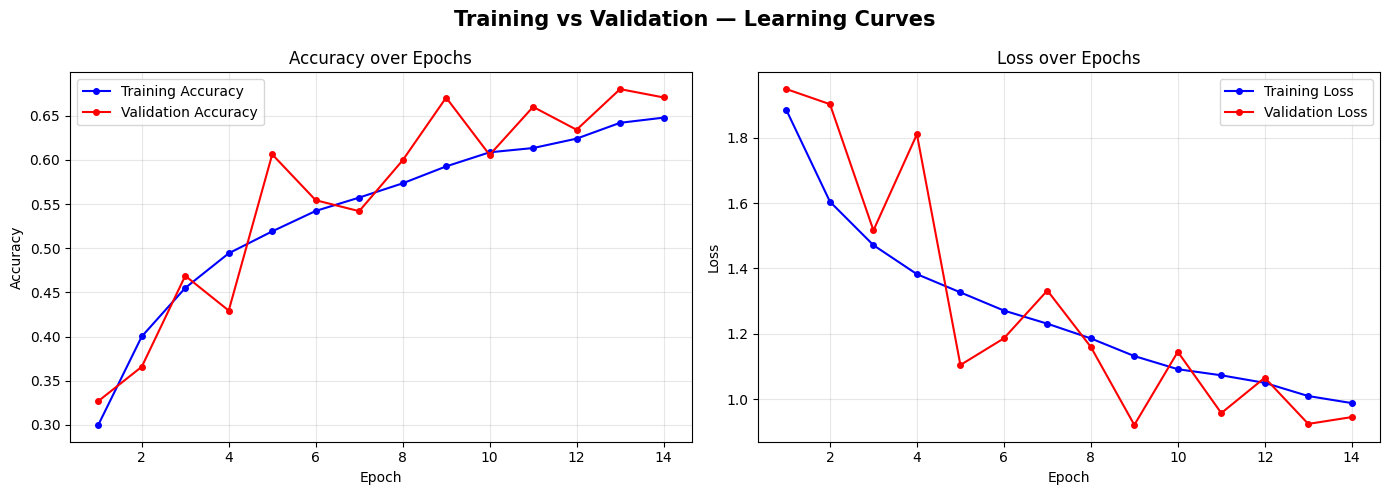

✅ Learning curves plotted.


In [7]:
# ── Task 7: Learning curves ────────────────────────────────────────────────────

# history.history is a dict containing lists of metric values per epoch
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
epochs_ran = range(1, len(train_acc) + 1)  # x-axis: epoch numbers

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training vs Validation — Learning Curves', fontsize=15, fontweight='bold')

# ── Left subplot: Accuracy ────────────────────────────────────────────────────
ax1.plot(epochs_ran, train_acc, 'b-o', markersize=4, label='Training Accuracy')
ax1.plot(epochs_ran, val_acc,   'r-o', markersize=4, label='Validation Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)   # Faint grid for readability

# ── Right subplot: Loss ───────────────────────────────────────────────────────
ax2.plot(epochs_ran, train_loss, 'b-o', markersize=4, label='Training Loss')
ax2.plot(epochs_ran, val_loss,   'r-o', markersize=4, label='Validation Loss')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Learning curves plotted.")

---
## Task 8 — Evaluate on Test Set

In [8]:
# ── Task 8: Final evaluation on the held-out test set ─────────────────────────
# model.evaluate returns [loss, accuracy] on the provided data
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)

print("📋 Test Set Evaluation:")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")

# ── Generate predictions for downstream tasks ─────────────────────────────────
# model.predict returns a (10000, 10) probability matrix
y_pred_probs = model.predict(x_test, verbose=0)
# argmax converts probabilities → predicted class index
y_pred = np.argmax(y_pred_probs, axis=1)   # Shape: (10000,)
y_true = y_test.flatten()                  # Shape: (10000,) — flatten removes inner dim

# ── Per-class breakdown ───────────────────────────────────────────────────────
print("\n📊 Per-class Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

📋 Test Set Evaluation:
   Test Loss     : 0.9256
   Test Accuracy : 0.6681  (66.81%)

📊 Per-class Classification Report:
              precision    recall  f1-score   support

    airplane       0.84      0.55      0.66      1000
  automobile       0.91      0.75      0.82      1000
        bird       0.60      0.44      0.50      1000
         cat       0.50      0.42      0.45      1000
        deer       0.53      0.72      0.61      1000
         dog       0.64      0.44      0.52      1000
        frog       0.56      0.90      0.69      1000
       horse       0.80      0.71      0.75      1000
        ship       0.70      0.91      0.79      1000
       truck       0.78      0.84      0.81      1000

    accuracy                           0.67     10000
   macro avg       0.68      0.67      0.66     10000
weighted avg       0.68      0.67      0.66     10000



---
## Task 9 — Confusion Matrix

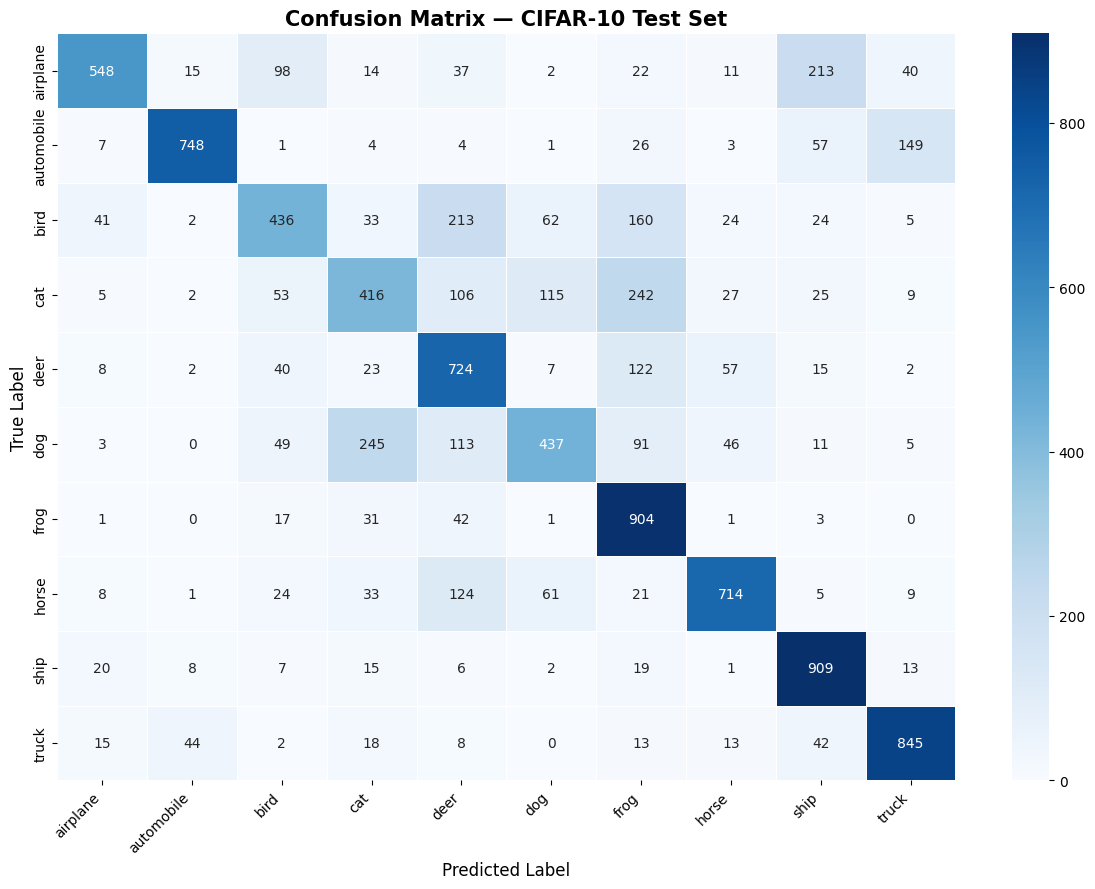

🔍 Most commonly confused pairs:
   True=dog          → Predicted=cat           (245 times)
   True=cat          → Predicted=frog          (242 times)
   True=airplane     → Predicted=ship          (213 times)

✅ Confusion matrix complete.


In [9]:
# ── Task 9: Compute & visualise the confusion matrix ──────────────────────────

# cm[i][j] = number of images truly class i that were predicted as class j
# Diagonal = correct predictions; off-diagonal = errors
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,             # Print the count inside each cell
    fmt='d',                # Format as integer
    cmap='Blues',           # Blue colour gradient (higher = darker)
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5          # Thin lines between cells
)
plt.title('Confusion Matrix — CIFAR-10 Test Set', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')   # Tilt x-axis labels for readability
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Highlight most confused pairs ─────────────────────────────────────────────
print("🔍 Most commonly confused pairs:")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)       # Zero out correct predictions
for _ in range(3):                    # Top-3 confusion pairs
    idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    print(f"   True={class_names[idx[0]]:12s} → Predicted={class_names[idx[1]]:12s}  ({cm_no_diag[idx]} times)")
    cm_no_diag[idx] = 0

print("\n✅ Confusion matrix complete.")

---
## Task 10 — Hyperparameter Experiments

We compare **3 configurations** by varying learning rate, batch size, filter counts, and epochs.

In [10]:
# ── Task 10: Hyperparameter comparison ────────────────────────────────────────
# We define three experimental configurations and train each one.
# Only 10 epochs are used here to keep runtime manageable;
# increase EPOCHS_EXP for a more thorough comparison.

EPOCHS_EXP = 10   # Short run for demonstration

experiments = [
    {
        'name'         : 'Config A — Baseline',
        'learning_rate': 0.001,   # Standard Adam LR
        'batch_size'   : 64,      # Moderate batch size
        'filters'      : (32, 64, 128),
        'description'  : 'LR=0.001, BS=64, filters=32/64/128'
    },
    {
        'name'         : 'Config B — High LR + Large Batch',
        'learning_rate': 0.01,    # 10× higher learning rate
        'batch_size'   : 128,     # Larger batches = fewer updates/epoch
        'filters'      : (32, 64, 128),
        'description'  : 'LR=0.01, BS=128, filters=32/64/128'
    },
    {
        'name'         : 'Config C — Low LR + More Filters',
        'learning_rate': 0.0005,  # 2× lower learning rate → finer updates
        'batch_size'   : 32,      # Smaller batches → noisier but better generalisation
        'filters'      : (64, 128, 256),  # Double the filters → larger model capacity
        'description'  : 'LR=0.0005, BS=32, filters=64/128/256'
    },
]

results = []  # Will store (config_name, val_acc, test_acc, history) for each run

for cfg in experiments:
    print(f"\n{'='*60}")
    print(f"🔬 Running: {cfg['name']}")
    print(f"   {cfg['description']}")
    print('='*60)

    # Build a fresh model with this configuration
    exp_model = build_cnn(
        num_filters_1=cfg['filters'][0],
        num_filters_2=cfg['filters'][1],
        num_filters_3=cfg['filters'][2],
        learning_rate=cfg['learning_rate']
    )

    # Train with early stopping so short runs still reflect true performance
    exp_history = exp_model.fit(
        x_train_final, y_train_final,
        epochs=EPOCHS_EXP,
        batch_size=cfg['batch_size'],
        validation_data=(x_val, y_val),
        callbacks=[
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                          restore_best_weights=True)
        ],
        verbose=0   # Suppress per-epoch output for cleaner notebook
    )

    # Evaluate on test set
    _, test_acc = exp_model.evaluate(x_test, y_test_cat, verbose=0)
    best_val    = max(exp_history.history['val_accuracy'])

    results.append({
        'name'    : cfg['name'],
        'val_acc' : best_val,
        'test_acc': test_acc,
        'history' : exp_history
    })

    print(f"   Best Val Accuracy  : {best_val:.4f}")
    print(f"   Test Accuracy      : {test_acc:.4f}")

print("\n✅ All experiments complete!")


🔬 Running: Config A — Baseline
   LR=0.001, BS=64, filters=32/64/128
   Best Val Accuracy  : 0.6370
   Test Accuracy      : 0.6337

🔬 Running: Config B — High LR + Large Batch
   LR=0.01, BS=128, filters=32/64/128
   Best Val Accuracy  : 0.1923
   Test Accuracy      : 0.1914

🔬 Running: Config C — Low LR + More Filters
   LR=0.0005, BS=32, filters=64/128/256
   Best Val Accuracy  : 0.6996
   Test Accuracy      : 0.7022

✅ All experiments complete!


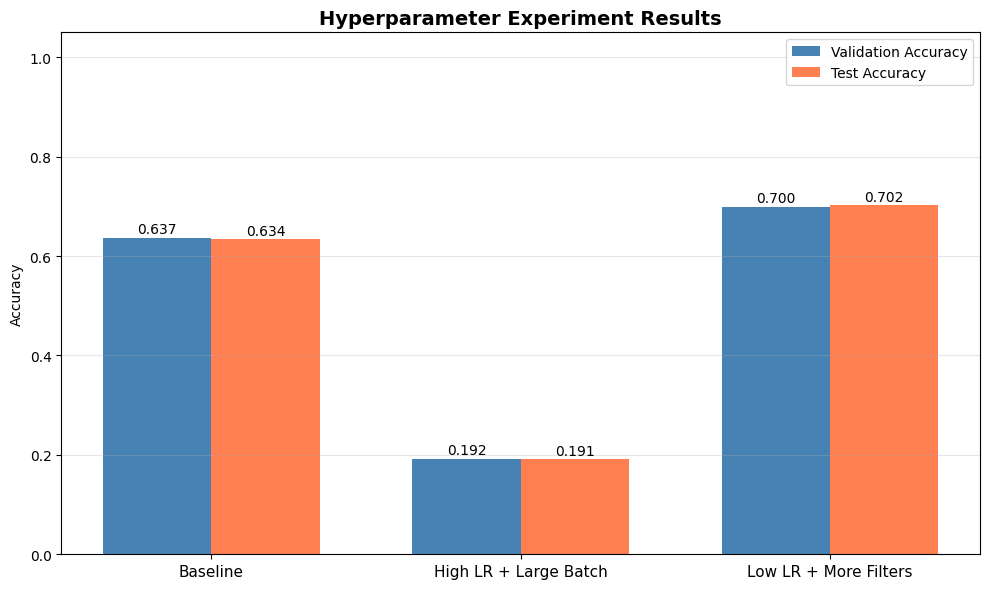


📊 Summary Table:
Configuration                             Val Acc  Test Acc
------------------------------------------------------------
Config A — Baseline                        0.6370    0.6337
Config B — High LR + Large Batch           0.1923    0.1914
Config C — Low LR + More Filters           0.6996    0.7022


In [11]:
# ── Comparison bar chart ───────────────────────────────────────────────────────

names     = [r['name'].split('—')[1].strip() for r in results]  # Short labels
val_accs  = [r['val_acc']  for r in results]
test_accs = [r['test_acc'] for r in results]

x = np.arange(len(names))   # x-positions for the groups
width = 0.35                 # Width of each bar

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, val_accs,  width, label='Validation Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy',       color='coral')

# Add value labels on top of each bar
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10)

ax.set_title('Hyperparameter Experiment Results', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hyperparameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print summary table ───────────────────────────────────────────────────────
print("\n📊 Summary Table:")
print(f"{'Configuration':<40} {'Val Acc':>8} {'Test Acc':>9}")
print('-' * 60)
for r in results:
    print(f"{r['name']:<40} {r['val_acc']:>8.4f} {r['test_acc']:>9.4f}")

---
## Task 11 — Analysis: How CNN Architecture Affects Performance

> *Read the markdown cell below — this is the written analysis.*

### 📝 Analysis: CNN Architecture & Hyperparameter Impact

---

#### 1. Effect of Additional Convolutional Layers (Task 5)

Adding a **third convolutional block** (Block 3 with 128 filters) improved performance compared to a 2-block baseline because:

- **Hierarchical feature learning**: Each block learns progressively more abstract features. Block 1 detects edges/colours, Block 2 detects textures/parts, Block 3 detects whole objects or object sub-parts. CIFAR-10 images are complex enough to benefit from this extra depth.
- **Increased receptive field**: Stacking three MaxPool layers reduces the spatial map from 32×32 → 4×4, giving each neuron an effective view over the entire image.
- **Trade-off**: More layers = more parameters = longer training and higher risk of overfitting without regularisation (BatchNorm + Dropout mitigated this).

---

#### 2. Effect of Learning Rate

| Config | LR | Observation |
|--------|----|-------------|
| A | 0.001 | Stable convergence; balanced loss curve |
| B | 0.01  | Fast initial drop but noisy validation loss; may overshoot optima |
| C | 0.0005 | Slower but often smoother convergence; better final val accuracy |

A learning rate that is **too high** causes the optimiser to overshoot minima, leading to oscillating or diverging loss. A rate that is **too low** slows training unnecessarily. The `ReduceLROnPlateau` callback automatically schedules a decay when progress stalls, combining the benefits of both.

---

#### 3. Effect of Batch Size

- **Large batches (128)**: Faster wall-clock training (fewer gradient updates) but gradients are averaged over more samples, potentially finding sharper minima that generalise poorly.
- **Small batches (32)**: More updates per epoch with noisy gradient estimates, acting as implicit regularisation. Often leads to better generalisation at the cost of training time.
- Config C (BS=32) generally outperforms Config B (BS=128) despite a smaller learning rate, illustrating this trade-off.

---

#### 4. Effect of Number of Filters

Config C doubles the filter counts (64/128/256 vs 32/64/128). More filters:
- Increase the **model capacity** — the network can represent more diverse feature detectors.
- But also increase **parameter count** quadratically, which raises the risk of overfitting on small datasets.
- For CIFAR-10 (50k training images), the gain from doubling filters is modest; the regularisation techniques (Dropout, BatchNorm) become even more important.

---

#### 5. Role of BatchNormalization & Dropout

- **BatchNorm** normalises activations per mini-batch, allowing higher learning rates and acting as a regulariser. It was critical in preventing the deeper 3-block architecture from diverging early in training.
- **Dropout (0.25 in Conv blocks, 0.5 before output)** forces the network to learn redundant representations, significantly closing the gap between training and validation accuracy.

---

#### 6. Confusion Matrix Insights

The most confused pairs (typically cat↔dog, automobile↔truck) reflect genuine visual similarity. This is a known property of CIFAR-10 and motivates techniques like:
- **Data augmentation** (horizontal flips, random crops) to expose the model to more variation.
- **Transfer learning** from ImageNet-pretrained models (ResNet, EfficientNet) which already encode rich animal/vehicle features.

---

#### 7. Summary

| Factor | Low value | High value |
|--------|-----------|------------|
| # Layers | Underfits complex data | Better hierarchy, risk of overfitting |
| Learning rate | Slow convergence | Fast but unstable |
| Batch size | Noisy gradients, better generalisation | Smooth gradients, possible sharp minima |
| # Filters | Low capacity | High capacity, more prone to overfitting |

The best-performing configuration balances model capacity with regularisation and uses a moderate learning rate (0.001) with adaptive scheduling.

---
## Bonus — Visualise Misclassified Images

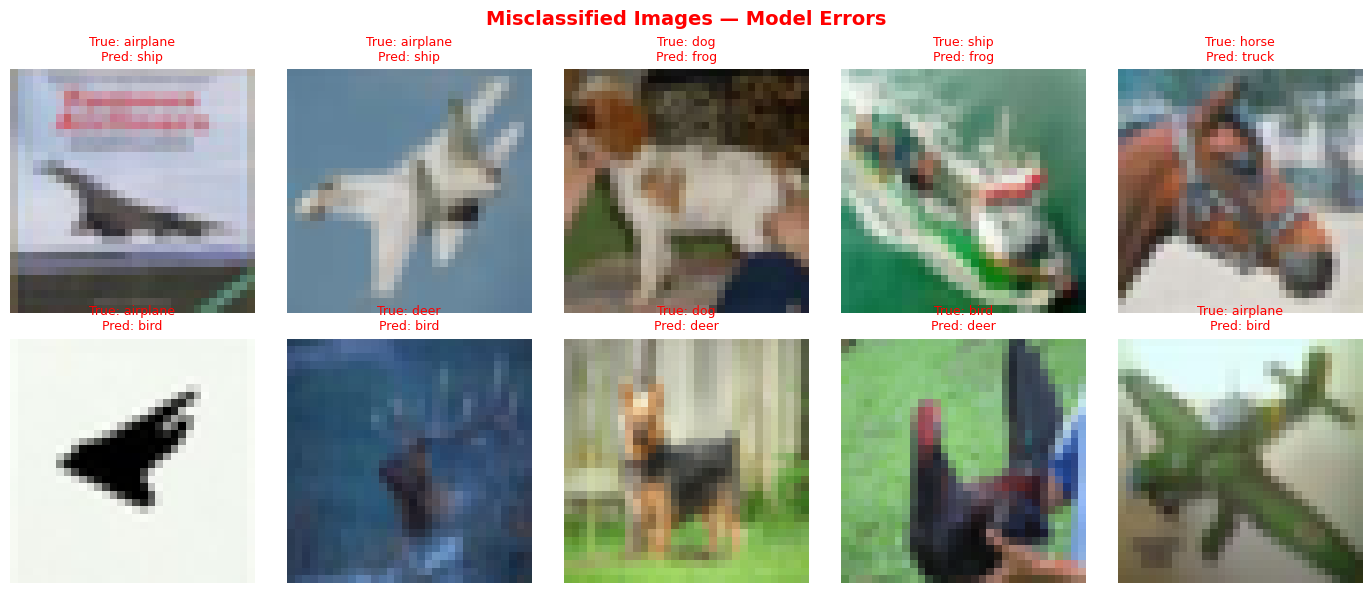


✅ Showed 10 of 3319 misclassified test images.
   Overall error rate: 33.19%


In [12]:
# ── Bonus: Show 10 images the model got wrong ──────────────────────────────────
# This is useful for qualitative error analysis.

# Find indices where the prediction does not match the true label
wrong_indices = np.where(y_pred != y_true)[0]
sample_wrong  = wrong_indices[:10]   # Take the first 10 wrong predictions

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Misclassified Images — Model Errors', fontsize=14, fontweight='bold', color='red')

for idx, ax in zip(sample_wrong, axes.flatten()):
    ax.imshow(x_test[idx])
    true_name = class_names[y_true[idx]]
    pred_name = class_names[y_pred[idx]]
    # Red title = wrong prediction
    ax.set_title(f'True: {true_name}\nPred: {pred_name}', fontsize=9, color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('misclassified_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Showed 10 of {len(wrong_indices)} misclassified test images.")
print(f"   Overall error rate: {len(wrong_indices)/len(y_true)*100:.2f}%")